<h2>Create and customize automated exploratory data analysis (EDA) reports using Pandas Profiling or Sweetviz, providing detailed statistical summaries, variable distributions, missing data visualizations, and data quality alerts for stakeholders.</h2>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r'C:\Users\rutva\Downloads\DS AIML Projects\Daily tasks\Pharmacy management system\archive\medicines.csv')

In [9]:
df

,,id,name,generic_name,category,description,strength,dosage_form,purchase_price,selling_price,mrp,current_stock,reorder_level,batch_number,expiry_date,supplier,manufacturer,is_prescription_required,is_seasonal,season_category
1,Amoxicillin 500mg,Amoxicillin,Antibiotics,Broad-spectrum antibiotic for bacterial infect...,urinary tract,and skin infections.,500mg,Capsule,12.0,25.0,30.0,120,20,AMX-2027-001,2027-08-15,Cipla Limited,Cipla Limited,TRUE,False,NaN
2,Azithromycin 500mg,Azithromycin,Antibiotics,Antibiotic for respiratory infections,skin infections,and ear infections.,500mg,Tablet,40.0,65.0,75.0,85,15,AZM-2027-002,2027-06-30,Sun Pharma,Sun Pharma,TRUE,True,Monsoon
3,Ciprofloxacin 500mg,Ciprofloxacin,Antibiotics,Broad-spectrum antibiotic for urinary tract in...,respiratory infections.,500mg,Tablet,25.00,45.0,55.0,60.0,10,CIP-2027-003,2027-09-20,Dr. Reddy's,Dr. Reddy's,TRUE,FALSE,NaN,NaN
4,Doxycycline 100mg,Doxycycline,Antibiotics,Tetracycline antibiotic for bacterial infections,acne,and malaria prophylaxis.,100mg,Capsule,18.0,35.0,42.0,95,15,DOX-2027-004,2027-11-10,Glenmark,Glenmark,TRUE,True,Summer
5,Metronidazole 400mg,Metronidazole,Antibiotics,Antibiotic for anaerobic bacterial infections ...,400mg,Tablet,8.00,15.00,20.0,150.0,25.0,MET-2027-006,2027-10-05,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN
6,Metformin 500mg,Metformin,Antidiabetics,First-line medication for type 2 diabetes. Red...,500mg,Tablet,5.00,10.00,15.0,200.0,30.0,MET-500-2027,2028-03-15,Cipla,Cipla,TRUE,FALSE,NaN,NaN,NaN
7,Glimepiride 2mg,Glimepiride,Antidiabetics,Sulfonylurea medication for type 2 diabetes.,2mg,Tablet,8.00,16.00,22.0,120.0,20.0,GLIM-2027-002,2027-12-20,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN
8,Empagliflozin 25mg,Empagliflozin,Antidiabetics,SGLT2 inhibitor for type 2 diabetes.,25mg,Tablet,50.00,85.00,100.0,55.0,10.0,EMPA-2027-005,2028-02-28,Cipla,Cipla,TRUE,FALSE,NaN,NaN,NaN
9,Amlodipine 5mg,Amlodipine,Antihypertensives,Calcium channel blocker for hypertension and a...,5mg,Tablet,4.00,8.00,12.0,180.0,25.0,AMLO-2027-001,2028-04-20,Dr. Reddy's,Dr. Reddy's,TRUE,FALSE,NaN,NaN,NaN
10,Losartan 50mg,Losartan,Antihypertensives,ARB for hypertension and diabetic nephropathy.,50mg,Tablet,6.00,12.00,18.0,150.0,20.0,LOS-2027-002,2028-06-10,Sun Pharma,Sun Pharma,TRUE,FALSE,NaN,NaN,NaN


In [10]:
num_cols = ['purchase_price', 'selling_price', 'mrp', 'current_stock']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

,count,mean,std,min,50%,max
purchase_price,30.0,35.866667,54.847584,6.0,18.0,280.0
selling_price,30.0,182.733333,128.713779,12.0,165.0,500.0
mrp,30.0,26.666667,13.588366,10.0,25.0,75.0
current_stock,5.0,98.000000,61.502032,10.0,95.0,180.0


In [12]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_df)

,Missing Count,Missing Percentage (%)
id,0,0.00
name,0,0.00
generic_name,0,0.00
category,0,0.00
description,0,0.00
strength,0,0.00
dosage_form,0,0.00
purchase_price,0,0.00
selling_price,0,0.00
mrp,0,0.00


C:\Users\rutva\AppData\Local\Temp\ipykernel_9376\1206914036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df['Missing Percentage (%)'], palette='Reds_r')


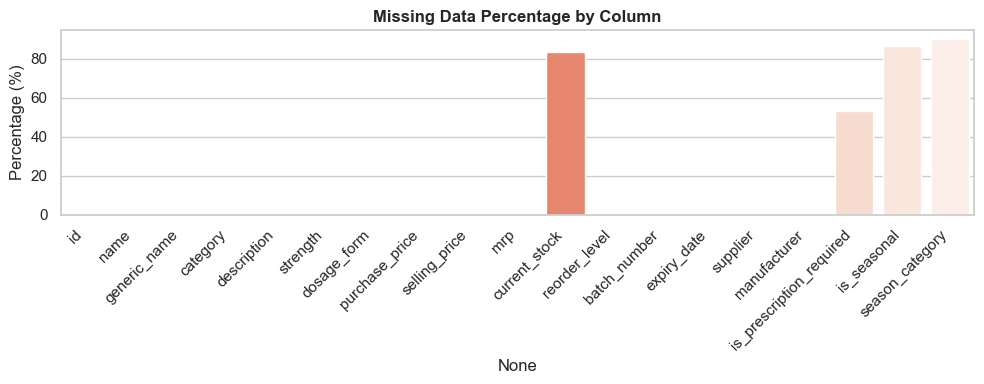

In [13]:
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing Percentage (%)'], palette='Reds_r')
plt.title('Missing Data Percentage by Column', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage (%)')
plt.tight_layout()
plt.show()

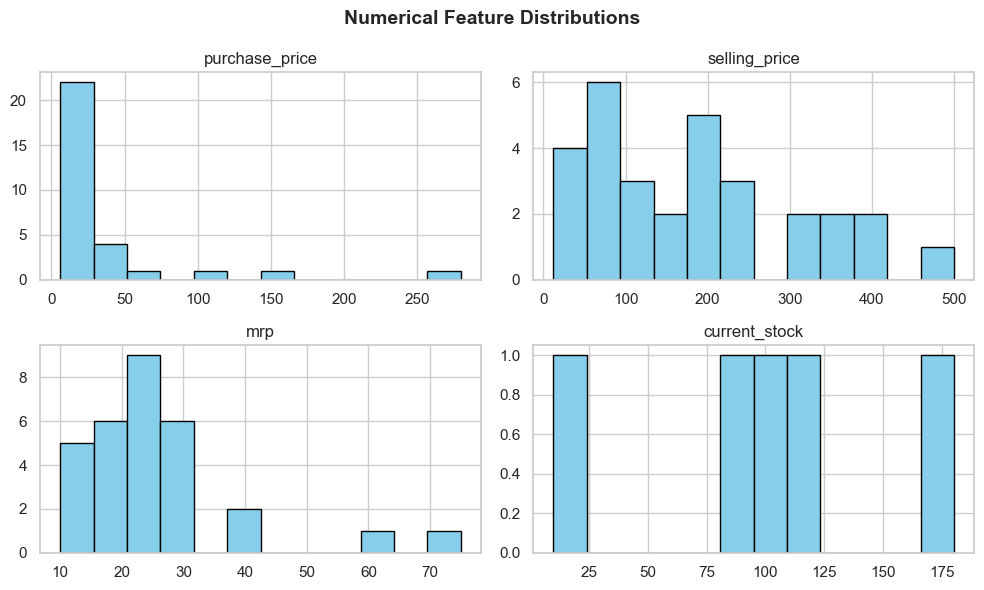

In [14]:
df[num_cols].hist(figsize=(10, 6), bins=12, color='skyblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    if missing_pct > 50:
        print(f"HIGH MISSINGNESS ALERT: Variable '{col}' has {missing_pct:.1f}% missing values!")

HIGH MISSINGNESS ALERT: Variable 'current_stock' has 83.3% missing values!
HIGH MISSINGNESS ALERT: Variable 'is_prescription_required' has 53.3% missing values!
HIGH MISSINGNESS ALERT: Variable 'is_seasonal' has 86.7% missing values!
HIGH MISSINGNESS ALERT: Variable 'season_category' has 90.0% missing values!


In [18]:
valid_num_cols = [c for c in num_cols if df[c].dropna().nunique() > 1]
if len(valid_num_cols) > 1:
    corr_matrix = df[valid_num_cols].corr().abs()
    np.fill_diagonal(corr_matrix.values, 0)
    high_corr_pairs = [(corr_matrix.index[i], corr_matrix.columns[j]) 
                       for i in range(len(corr_matrix)) 
                       for j in range(i+1, len(corr_matrix)) 
                       if corr_matrix.iloc[i, j] > 0.85]
    for pair in high_corr_pairs:
        print(f"MULTICOLLINEARITY ALERT: High correlation detected between '{pair[0]}' and '{pair[1]}'!")

MULTICOLLINEARITY ALERT: High correlation detected between 'purchase_price' and 'current_stock'!
